In [172]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import sys 
sys.path.append('./../src/')
import kde_function as f

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

import seaborn as sns

import matplotlib
%matplotlib inline

from scipy import interpolate

from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import mean_pinball_loss, make_scorer
from sklearn.model_selection import cross_val_score, KFold

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import QuantileRegressor



In [173]:
df = pd.read_csv('../data/processed/years_season_EFscale.csv', index_col=0)
dfall = pd.read_csv('../data/processed/tornadoes_all.csv', index_col=0)


In [174]:
df

,year,EF0,EF1,EF2,EF3,EF4,EF5,Nspring,Nsummer,Nautumn,Nwinter
0,1990,541,412,190,71,42,8,329,235,73,86
1,1991,694,313,128,61,10,2,360,91,40,23
2,1992,707,447,151,67,30,2,119,321,219,38
3,1993,242,134,37,7,3,0,92,27,45,17
4,1994,381,144,42,10,4,0,76,89,31,4
5,1995,478,168,57,13,9,0,147,50,32,18
6,1996,765,341,102,26,3,1,225,118,97,33
7,1997,756,294,89,31,9,1,169,131,75,49
8,1998,914,416,137,48,11,3,271,189,94,61
9,1999,885,381,164,69,16,2,311,135,24,162


In [175]:
dfall

,YEAR,MONTH,BEGIN_LAT,BEGIN_LON,TOR_F_SCALE
0,1990,6,44.3700,-92.6300,1
1,1990,5,42.0800,-71.4000,0
2,1990,6,41.1000,-98.4700,0
3,1990,6,41.5200,-97.7300,0
4,1990,6,40.2500,-100.7500,4
...,...,...,...,...,...
48229,2025,9,48.2490,-100.8390,-1
48230,2025,6,37.2391,-98.0398,0
48231,2025,9,47.1400,-100.1750,-1
48232,2025,6,36.1732,-101.1485,2


## First look at trends over year

### Reference for trends over longer period of time: https://repository.library.noaa.gov/view/noaa/69284 

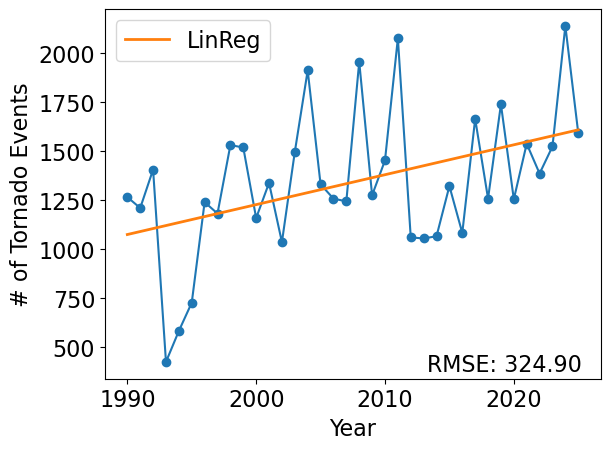

In [176]:
annual_totals_raw = dfall.groupby('YEAR').size().to_dict() # sums up number of tornadoes per year
unique_years = np.unique(X)

years_total = np.array(list(annual_totals_raw.keys()))
counts_total = np.array(list(annual_totals_raw.values()))

model = LinearRegression()
model.fit(years_total.reshape(-1,1),(counts_total))

total_slope = model.coef_[0]
total_intercept = model.intercept_

rmse = np.sqrt(mean_squared_error(counts_total, model.predict(years_total.reshape(-1,1)))) 

proj_total = lambda t: (total_slope * t + total_intercept)

plt.plot(years_total, counts_total, marker='o', linestyle='-')
plt.plot(years_total, (model.predict(years_total.reshape(-1,1))), linewidth = 2, linestyle='-', label='LinReg')
plt.xlabel('Year')
plt.ylabel('# of Tornado Events')
plt.annotate('RMSE: {:.2f}'.format(rmse), xy=(0.65, 0.02), xycoords='axes fraction')
plt.legend()

plt.savefig('../plots/Ntornados_year.pdf', bbox_inches='tight')

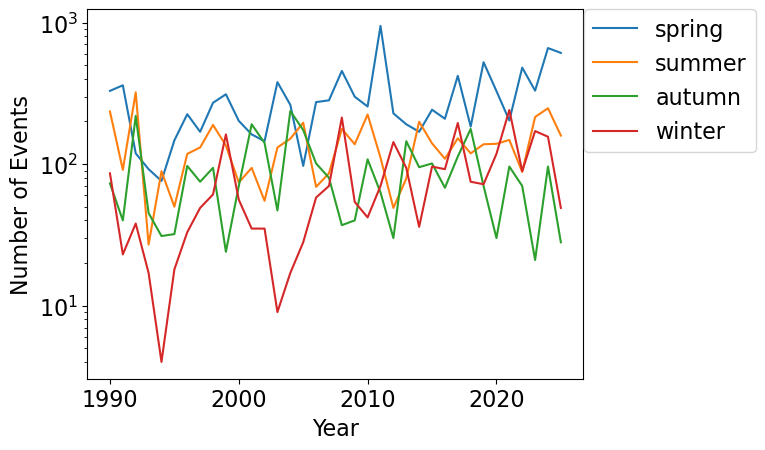

In [177]:
df = pd.read_csv('../data/processed/years_season_EFscale.csv', index_col=0)
dfall = pd.read_csv('../data/processed/tornadoes_all.csv', index_col=0)
plt.figure()
plt.plot(df.year, df.Nspring, label='spring')
plt.plot(df.year, df.Nsummer, label='summer')
plt.plot(df.year, df.Nautumn, label='autumn')
plt.plot(df.year, df.Nwinter, label='winter')
plt.xlabel('Year')
plt.legend(loc='upper right', bbox_to_anchor=(1.37, 1.03))
plt.ylabel('Number of Events')
plt.yscale('log')

Text(0, 0.5, 'Number of Events')

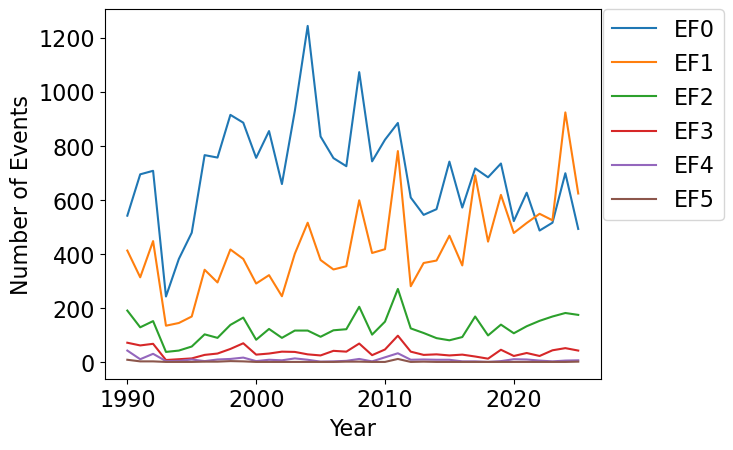

In [178]:
df = pd.read_csv('../data/processed/years_season_EFscale.csv', index_col=0)
dfall = pd.read_csv('../data/processed/tornadoes_all.csv', index_col=0)
plt.figure()
plt.plot(df.year, df.EF0, label='EF0')
plt.plot(df.year, df.EF1, label='EF1')
plt.plot(df.year, df.EF2, label='EF2')
plt.plot(df.year, df.EF3, label='EF3')
plt.plot(df.year, df.EF4, label='EF4')
plt.plot(df.year, df.EF5, label='EF5')
plt.legend(loc='upper right', bbox_to_anchor=(1.27, 1.03))
plt.xlabel('Year')
plt.ylabel('Number of Events')

### There's a lot of variation in number of tornadoes year to year, so to build a better model then we should normalize by total number of tornadoes each year.

## We will use bootstrapping in order to extrapolate & provide a confidence interval

In [180]:
def lin_reg(X_all, Y_all, X_train, Y_train, X_test, Y_test):
    X_all = X_all.reshape(-1,1)
    X_train = X_train.reshape(-1,1)
    X_test = X_test.reshape(-1,1)
    
    print('=========== LINEAR REGRESSION ============')
    loo = LeaveOneOut()
    
    model = LinearRegression()
    
    loo = LeaveOneOut()
    
    model.fit(X_train,Y_train)

    slope = model.coef_[0]
    intercept = model.intercept_

    X_plot = np.linspace(1990,2025,10)

    quantiles = [0.16, 0.50, 0.84]
    qr_models = {}
    for q in quantiles:
        qr = QuantileRegressor(quantile=q, alpha=0.0, solver="highs")
        qr.fit(X_all, Y_all)
        qr_models[q] = qr
        
    pred_lo  = qr_models[0.16].predict(X_plot.reshape(-1,1))
    pred_med = qr_models[0.50].predict(X_plot.reshape(-1,1))
    pred_hi  = qr_models[0.84].predict(X_plot.reshape(-1,1))

    Y_predict = model.predict(X_train)

    ### error on the slope:
    Ndata = len(X_train)
    dof = Ndata - 2 

    # critical t-value for 95% confidence
    t_critical = stats.t.ppf(0.975, df=dof)
    
    # Calculate Residual Standard Error (RSE)
    residuals = Y_train - Y_predict
    rse = np.sqrt(np.sum(residuals**2) / dof)
    
    # Calculate Standard Error of the slope
    x_mean = np.mean(X_all)
    ss_x = np.sum((X - x_mean)**2)
    se_slope = rse / np.sqrt(ss_x)
    
    slope_error = t_critical * se_slope

    print('slope={:.3f}'.format(slope)+', slope error={:.3f}'.format(slope_error))

    for n in range(0,2):
        if n == 0:
            X_in = X_train
            Y_in = Y_train
        elif n==1:
            X_in = X_test
            Y_in = Y_test
            
        neg_mse_scores = cross_val_score(
            estimator=model, 
            X=X_in, 
            y=Y_in, 
            scoring="neg_mean_squared_error", 
            cv=loo
        )

        Y_pass = model.predict(X_in)
        
        # MODEL Mean Squared Error and calculate RMSE
        mse_scores = -neg_mse_scores
        average_mse = np.mean(mse_scores)

        if n == 0:
            train_rmse = np.sqrt(average_mse)
        elif n==1:
            test_rmse = np.sqrt(average_mse)

    
    print('train_rmse={:.3f}'.format(train_rmse)+', test_rmse={:.3f}'.format(test_rmse))
    
    return model, slope, slope_error, intercept, train_rmse, test_rmse, X_plot, Y_predict, pred_lo, pred_hi


def nonpara(X,Y, X_train, Y_train, X_test, Y_test):
    X = X.reshape(-1,1)
    X_train = X_train.reshape(-1,1)
    X_test = X_test.reshape(-1,1)
    
    print('=========== NON-PARAMETRIC REGRESSION ============')
    loo = LeaveOneOut()
    
    nonparametric_model = KernelRidge(kernel='rbf')
    param_grid = {"alpha":    [10**(-k) for k in range(-5, 5)],
                  "gamma": [10**(k) for k in range(-5,5)]}
    
    search = GridSearchCV(nonparametric_model, param_grid, cv=5).fit(X, Y)
    
    print("The best hyperparameters are ",search.best_params_)

    nonparametric_model = KernelRidge(kernel = 'rbf', **search.best_params_) # ** "unpacks" the dict of params into kwarg assignments
    nonparametric_model.fit(X_train, Y_train)

    Y_predict = nonparametric_model.predict(X_train)

    # to plot 16th & 84th percentiles
    quantiles = [0.16, 0.50, 0.84]
    qr_models = {}
    for q in quantiles:
        qr = QuantileRegressor(quantile=q, alpha=0.0, solver="highs")
        qr.fit(X, Y)
        qr_models[q] = qr
    pred_lo  = qr_models[0.16].predict(X_plot.reshape(-1,1))
    pred_med = qr_models[0.50].predict(X_plot.reshape(-1,1))
    pred_hi  = qr_models[0.84].predict(X_plot.reshape(-1,1))

    for n in range(0,2):
        if n == 0:
            X_in = X_train
            Y_in = Y_train
        elif n==1:
            X_in = X_test
            Y_in = Y_test
            
        neg_mse_scores = cross_val_score(
                            estimator=nonparametric_model, 
                            X=X_in, 
                            y=Y_in, 
                            scoring="neg_mean_squared_error", 
                            cv=loo
                        )

        Y_pass = model.predict(X_in)
        
        # MODEL Mean Squared Error and calculate RMSE
        mse_scores = -neg_mse_scores
        average_mse = np.mean(mse_scores)

        if n == 0:
            train_rmse = np.sqrt(average_mse)
        elif n==1:
            test_rmse = np.sqrt(average_mse)

    Xplot = np.linspace(1990,2025,10)
    
    print('train_rmse={:.3f}'.format(train_rmse)+', test_rmse={:.3f}'.format(test_rmse))
    
    return nonparametric_model, train_rmse, test_rmse, X_plot, Y_predict, pred_lo, pred_hi


def linreg_forecast(X_train, Y_train, Y_predict, X_forecast, slope, intercept, n_boot=5000):
    residuals = Y_train - Y_predict

    linear_trend_forecast = slope * X_forecast + intercept
    
    bootstrap_forecasts = np.zeros((n_boot, len(X_forecast)))
    
    for b in range(n_boot):
        boot_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
    
        # construct a new 'training' set with newly sampled & replaced data
        Y_boot = Y_predict + boot_residuals
    
        # Refit regression
        boot_reg = LinearRegression()
        boot_reg.fit(X_train.reshape(-1,1), Y_boot)
    
        # Forecast
        bootstrap_forecasts[b] = boot_reg.predict(
            X_forecast.reshape(-1,1)
        )
    
    lower = np.percentile(bootstrap_forecasts, 2.5, axis=0)
    upper = np.percentile(bootstrap_forecasts, 97.5, axis=0)
    median = np.percentile(bootstrap_forecasts, 50, axis=0)

    return linear_trend_forecast, bootstrap_forecasts, lower, upper, median

def nonpara_forecast(nonparametric_model, X_train, Y_train, Y_predict, X_forecast, n_boot=5000):

    X_train = X_train.reshape(-1,1)
    X_forecast = X_forecast.reshape(-1,1)

    # residuals from original fit
    residuals = Y_train - Y_predict

    # original forecast
    forecast = nonparametric_model.predict(X_forecast)

    bootstrap_forecasts = np.zeros((n_boot, len(X_forecast)))

    # recover tuned hyperparameters
    alpha = nonparametric_model.alpha
    gamma = nonparametric_model.gamma

    for b in range(n_boot):

        # bootstrap residuals
        boot_residuals = np.random.choice(
            residuals,
            size=len(residuals),
            replace=True
        )

        # bootstrap response
        Y_boot = Y_predict + boot_residuals

        # refit Kernel Ridge with same tuning parameters
        boot_model = KernelRidge(
            kernel='rbf',
            alpha=alpha,
            gamma=gamma
        )

        boot_model.fit(X_train, Y_boot)

        # forecast
        bootstrap_forecasts[b] = boot_model.predict(X_forecast)

    lower = np.percentile(bootstrap_forecasts, 2.5, axis=0)
    median = np.percentile(bootstrap_forecasts, 50, axis=0)
    upper = np.percentile(bootstrap_forecasts, 97.5, axis=0)

    return forecast, bootstrap_forecasts, lower, upper, median

# Compare LinReg and Nonparametric models to fit our trends over time!

## Based on RMSE, we will use a certain trained model to do a drift forecast for future years.

=========== LINEAR REGRESSION ============
slope=0.002, slope error=0.000
train_rmse=0.115, test_rmse=0.116
=========== NON-PARAMETRIC REGRESSION ============
The best hyperparameters are  {'alpha': 1, 'gamma': 1e-05}
train_rmse=0.114, test_rmse=0.116
# of tornadoes (spring lower/upper bound) expected in 2030: 689, 805 events
=========== LINEAR REGRESSION ============
slope=-0.003, slope error=0.000
train_rmse=0.084, test_rmse=0.094
=========== NON-PARAMETRIC REGRESSION ============
The best hyperparameters are  {'alpha': 0.0001, 'gamma': 0.0001}
train_rmse=0.087, test_rmse=0.097
# of tornadoes (summer lower/upper bound) expected in 2030: 294, 502 events
=========== LINEAR REGRESSION ============
slope=-0.002, slope error=0.000
train_rmse=0.075, test_rmse=0.065
=========== NON-PARAMETRIC REGRESSION ============
The best hyperparameters are  {'alpha': 1, 'gamma': 0.001}
train_rmse=0.073, test_rmse=0.063
# of tornadoes (autumn lower/upper bound) expected in 2030: 78, 222 events
=========

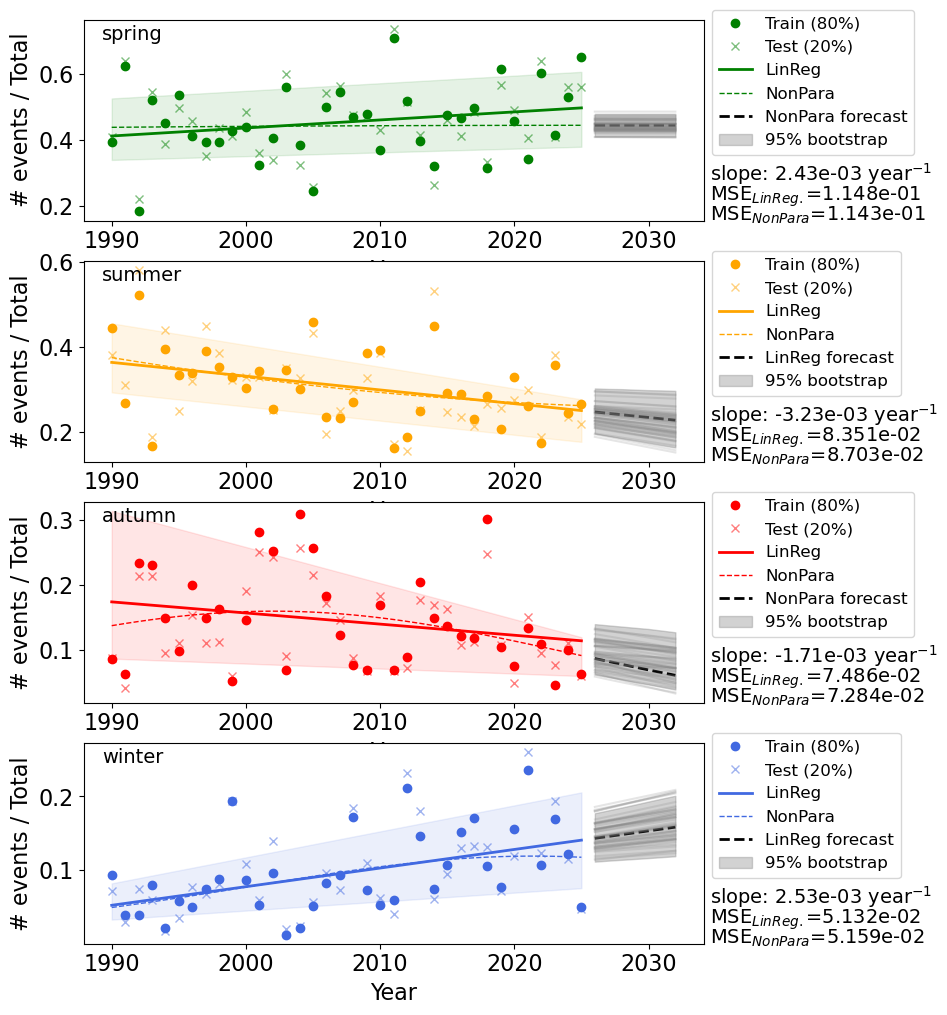

In [181]:
dfall = pd.read_csv('../data/processed/tornadoes_all.csv', index_col=0)

X = np.array(dfall.YEAR)
y = np.array(dfall.MONTH)

# shuffle indices for subsampling all tornado events
shuffled_indices = np.random.permutation(len(X))

# 80% of data in training set
split_idx = int(0.8 * len(X))

X_train_raw = X[shuffled_indices[:split_idx]]
X_test_raw = X[shuffled_indices[split_idx:]]

y_train_raw = y[shuffled_indices[:split_idx]]
y_test_raw = y[shuffled_indices[split_idx:]]

# sums up number of tornadoes per year
annual_totals_raw = dfall.groupby('YEAR').size().to_dict()
unique_years = np.unique(X)

def get_season(month):
    if month in [3,4,5]: return 'spring'
    elif month in [6,7,8]: return 'summer'
    elif month in [9,10,11]: return 'autumn'
    elif month in [12,1,2]: return 'winter'

def aggregate_to_seasonal_proportions(years, months, all_years_range, annual_totals, split_ratio):
    # Counts seasonal events and normalizes by annual totals.

    df_temp = pd.DataFrame({'year': years, 'month': months})
    df_temp['season'] = df_temp['month'].apply(get_season)

    counts = df_temp.groupby(['year', 'season']).size().unstack(fill_value=0)
    counts = counts.reindex(index=all_years_range, fill_value=0)

    df_norm = pd.DataFrame(index=all_years_range)

    for s in ['spring', 'summer', 'autumn', 'winter']:

        raw_counts = (
            counts[s].values
            if s in counts.columns
            else np.zeros(len(all_years_range))
        )

        expected_split_total = np.array([
            annual_totals[yr] * split_ratio
            for yr in all_years_range
        ])

        proportions = np.divide(
            raw_counts,
            expected_split_total,
            out=np.zeros_like(raw_counts, dtype=float),
            where=expected_split_total != 0
        )

        df_norm[f'N{s}'] = proportions

    return df_norm

unique_years = np.unique(X)

# Aggregate both datasets normalized by their respective 80% and 20% annual scales
df_train_season = aggregate_to_seasonal_proportions(X_train_raw, y_train_raw, unique_years, annual_totals_raw, split_ratio=0.80)
df_test_season = aggregate_to_seasonal_proportions(X_test_raw, y_test_raw, unique_years, annual_totals_raw, split_ratio=0.20)

seasons = ['spring', 'summer', 'autumn', 'winter']
colors = ['green', 'orange', 'red', 'royalblue']
fig, ax = plt.subplots(4, 1, figsize=(8,12))

X_global = unique_years 
per = 0.2
split_offset = round(len(X_global) * per)
X_forecast = np.arange(2026, 2026 + split_offset)

for n, season in enumerate(seasons):
    X_train = unique_years
    X_test = unique_years
    Y_train = df_train_season[f'N{season}'].values
    Y_test = df_test_season[f'N{season}'].values
    
    Y_global = (Y_train + Y_test) / 2.0
    
    model, slope, slope_error, intercept, train_rmse, test_rmse, X_plot, Y_predict, pred_lo, pred_hi = lin_reg(
        X_global, Y_global, X_train, Y_train, X_test, Y_test)
    
    nonparametric_model, nonp_train_rmse, nonp_test_rmse, X_plot, nonp_Y_predict, pred_lo, pred_hi = nonpara(
        X_global, Y_global, X_train, Y_train, X_test, Y_test)

    ### to do the drift forecast, we will use a model based on the one with lower RMSE:
    if nonp_train_rmse < train_rmse:

        forecast, bootstrap_forecasts, lower, upper, median = nonpara_forecast(nonparametric_model, 
                                                                    X_train, Y_train, Y_predict, X_forecast, n_boot=5000)
        forecast_label = 'NonPara forecast'
    else:
        forecast, bootstrap_forecasts, lower, upper, median = linreg_forecast(
                                                                    X_train, Y_train, Y_predict, X_forecast, slope, intercept, n_boot=5000)
        forecast_label = 'LinReg forecast'
    
    ax[n].plot(X_train, Y_train, color=colors[n], marker='o', linestyle='', label='Train (80%)')
    ax[n].plot(X_test, Y_test, color=colors[n], marker='x', alpha = 0.5, linestyle='', label='Test (20%)')
    
    ax[n].fill_between(X_plot, pred_lo, pred_hi, alpha=0.1, color=colors[n])
    ax[n].plot(X_train, Y_predict, linewidth=2, label='LinReg', color=colors[n])
    ax[n].plot(X_train, nonp_Y_predict, linewidth=1, linestyle='dashed', label='NonPara', color=colors[n])
    
    ax[n].plot(X_forecast, forecast, 'k--', lw=2, label=forecast_label)
        
    for i in range(50):
        ax[n].plot(X_forecast, bootstrap_forecasts[i], color='gray', alpha=0.2)
    
    ax[n].fill_between(X_forecast, lower, upper, color='gray', alpha=0.35, label='95% bootstrap')

    #ax[n].set_ylim([0,1])
    ax[n].set_ylabel('# events / Total')
    ax[n].set_xlabel('Year')
    f_lower = interpolate.interp1d(X_forecast, lower)
    f_upper = interpolate.interp1d(X_forecast, upper)

    ax[n].annotate('slope: {:.2e}'.format(slope)+' year$^{-1}$', xy=(1.01, 0.2), xycoords='axes fraction', fontsize=14)
    ax[n].annotate('MSE$_{LinReg.}$'+'={:.3e}'.format(train_rmse), xy=(1.01, 0.1), xycoords='axes fraction', fontsize=14)
    ax[n].annotate('MSE$_{NonPara}$'+'={:.3e}'.format(nonp_train_rmse), xy=(1.01, 0.0), xycoords='axes fraction', fontsize=14)
    ax[n].annotate(season, xy=(0.03, 0.9), xycoords='axes fraction', fontsize=14)
    ax[n].legend(loc='upper left', fontsize=12, bbox_to_anchor=(1.0, 1.09))
    
    prop_lower_2030 = max(0, (f_lower(2030))) # sets 1 event as the lower limit (still in log10-scale)
    prop_upper_2030 = max(0, (f_upper(2030)))
    
    abs_lower_2030 = prop_lower_2030 * proj_total(2030)
    abs_upper_2030 = prop_upper_2030 * proj_total(2030)
    
    print(f'# of tornadoes ({season} lower/upper bound) expected in 2030: {round(abs_lower_2030)}, {round(abs_upper_2030)} events')

fig.savefig('../plots/seasons_year_forecast.pdf', bbox_inches='tight')

=========== LINEAR REGRESSION ============
slope=-0.007, slope error=0.000
train_rmse=0.079, test_rmse=0.098
=========== NON-PARAMETRIC REGRESSION ============
The best hyperparameters are  {'alpha': 0.0001, 'gamma': 0.0001}
train_rmse=0.050, test_rmse=0.072
# of EF 0 tornadoes lower/upper bound expected in 2030: 415, 820 events
=========== LINEAR REGRESSION ============
slope=0.004, slope error=0.000
train_rmse=0.040, test_rmse=0.047
=========== NON-PARAMETRIC REGRESSION ============
The best hyperparameters are  {'alpha': 0.001, 'gamma': 0.001}
train_rmse=0.032, test_rmse=0.043
# of EF 1 tornadoes lower/upper bound expected in 2030: 472, 853 events
=========== LINEAR REGRESSION ============
slope=0.000, slope error=0.000
train_rmse=0.022, test_rmse=0.024
=========== NON-PARAMETRIC REGRESSION ============
The best hyperparameters are  {'alpha': 1, 'gamma': 1e-05}
train_rmse=0.022, test_rmse=0.024
# of EF 2 tornadoes lower/upper bound expected in 2030: 141, 163 events
=========== LINEA

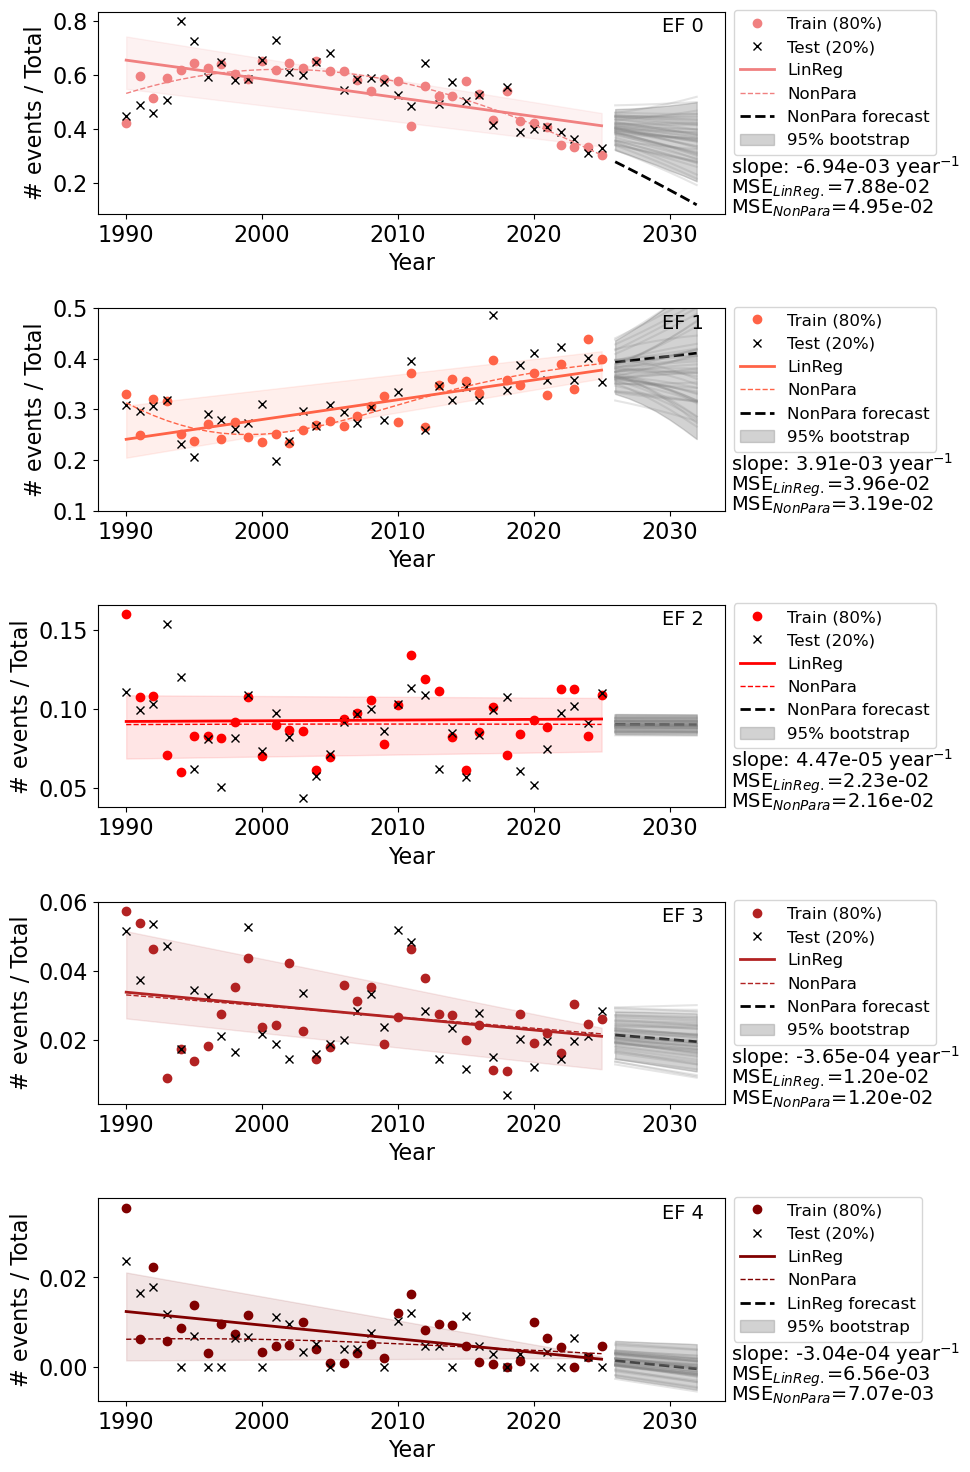

In [183]:

# Identify all unique EF scales present in the dataset (ordered)
ef_scales = sorted(dfall.TOR_F_SCALE.unique())[1:-1] # ignore "unknown" category (EFU, labeled as -1)

dfall = pd.read_csv('../data/processed/tornadoes_all.csv', index_col=0)

X = np.array(dfall.YEAR)
y = np.array(dfall.TOR_F_SCALE)

all_ef_labels = [0,1,2,3,4]

# shuffle indices for subsampling all tornado events
shuffled_indices = np.random.permutation(len(X))

# 80% of data in training set
split_idx = int(0.8 * len(X))

X_train_raw = X[shuffled_indices[:split_idx]]
X_test_raw = X[shuffled_indices[split_idx:]]

y_train_raw = y[shuffled_indices[:split_idx]]
y_test_raw = y[shuffled_indices[split_idx:]]

# sums up number of tornadoes per year
annual_totals_raw = dfall.groupby('YEAR').size().to_dict()
unique_years = np.unique(X)

def aggregate_to_ef_proportions(years, scales, all_years_range, annual_totals, split_ratio, all_ef_labels):
    # Counts EF-scale events, normalizes by total annual events
    df_temp = pd.DataFrame({'year': years, 'ef_scale': scales})
    
    # Count raw events per year/EF-scale
    counts = df_temp.groupby(['year', 'ef_scale']).size().unstack(fill_value=0)
    counts = counts.reindex(index=all_years_range, fill_value=0)
    
    df_norm = pd.DataFrame(index=all_years_range)
    for ef in all_ef_labels:
        # Extract raw counts for specific EF scale
        raw_counts = counts[ef].values if ef in counts.columns else np.zeros(len(all_years_range))
        expected_split_total = np.array([annual_totals[yr] * split_ratio for yr in all_years_range])
        
        # Calculate proportion of total events that year falling into this specific EF category
        proportions = np.divide(raw_counts, expected_split_total, out=np.zeros_like(raw_counts, dtype=float), where=expected_split_total!=0)
        df_norm[f'EF_{ef}'] = proportions
        
    return df_norm

df_train_ef = aggregate_to_ef_proportions(X_train_raw, y_train_raw, unique_years, annual_totals_raw, split_ratio=0.80, all_ef_labels=ef_scales)
df_test_ef = aggregate_to_ef_proportions(X_test_raw, y_test_raw, unique_years, annual_totals_raw, split_ratio=0.20, all_ef_labels=ef_scales)

fig, ax = plt.subplots(len(ef_scales), 1, figsize=(10, 3 * len(ef_scales)))

X_global = unique_years 
per = 0.2
split_offset = round(len(X_global) * per)
X_forecast = np.arange(2026, 2026 + split_offset)

colors = ['lightcoral', 'tomato', 'red', 'firebrick', 'maroon']

for n, ef in enumerate(ef_scales):
    X_train = unique_years
    X_test = unique_years
    
    Y_train = df_train_ef[f'EF_{ef}'].values
    Y_test = df_test_ef[f'EF_{ef}'].values
    Y_global = ((Y_train + Y_test) / 2.0)
    
    model, slope, slope_error, intercept, train_rmse, test_rmse, X_plot, Y_predict, pred_lo, pred_hi = lin_reg(
        X_global, Y_global, X_train, Y_train, X_test, Y_test
    )
    nonpara_model, nonp_train_rmse, nonp_test_rmse, X_plot, nonp_Y_predict, pred_lo, pred_hi = nonpara(
        X_global, Y_global, X_train, Y_train, X_test, Y_test
    )
    
    ### to do the drift forecast, we will use a model based on the one with lower RMSE:
    if nonp_train_rmse < train_rmse:

        forecast, bootstrap_forecasts, lower, upper, median = nonpara_forecast(nonpara_model, 
                                                                    X_train, Y_train, Y_predict, X_forecast, n_boot=5000)
        forecast_label = 'NonPara forecast'
    else:
        forecast, bootstrap_forecasts, lower, upper, median = linreg_forecast(
                                                                    X_train, Y_train, Y_predict, X_forecast, slope, intercept, n_boot=5000)
        forecast_label = 'LinReg forecast'
    
    ax[n].plot(X_train, Y_train, color=colors[n], marker='o', linestyle='', label='Train (80%)')
    ax[n].plot(X_test, Y_test, color='black', marker='x',  linestyle='', label='Test (20%)')
    ax[n].fill_between(X_plot, pred_lo, pred_hi, alpha=0.1, color=colors[n])
    ax[n].plot(X_train, Y_predict, linewidth=2, label='LinReg', color=colors[n])
    ax[n].plot(X_train, nonp_Y_predict, linewidth=1, linestyle='dashed', label='NonPara', color=colors[n])
    
    ax[n].plot(X_forecast, forecast, 'k--', lw=2, label=forecast_label)
        
    for i in range(50):
        ax[n].plot(X_forecast, bootstrap_forecasts[i], color='gray', alpha=0.2)
    ax[n].fill_between(X_forecast, lower, upper, color='gray', alpha=0.35, label='95% bootstrap')
    
    f_lower = interpolate.interp1d(X_forecast, lower)
    f_upper = interpolate.interp1d(X_forecast, upper)

    ax[n].annotate('slope: {:.2e}'.format(slope)+' year$^{-1}$', xy=(1.01, 0.2), xycoords='axes fraction', fontsize=14)
    ax[n].annotate('MSE$_{LinReg.}$'+'={:.2e}'.format(train_rmse), xy=(1.01, 0.1), xycoords='axes fraction', fontsize=14)
    ax[n].annotate('MSE$_{NonPara}$'+'={:.2e}'.format(nonp_train_rmse), xy=(1.01, 0.), xycoords='axes fraction', fontsize=14)
    ax[n].annotate(f'EF {ef}', xy=(0.9, 0.9), xycoords='axes fraction', fontsize=14)
    ax[n].legend(loc='upper left', fontsize=12, bbox_to_anchor=(1.0, 1.05))
    ax[n].set_xlabel('Year')
    ax[n].set_ylabel('# events / Total')

    if ef == 1:
        ax[n].set_ylim([0.1, 0.5])
    
    prop_lower_2030 = max(0, (f_lower(2030))) # ensures lower bound of 0 events
    prop_upper_2030 = max(0, (f_upper(2030)))
    
    abs_lower_2030 = prop_lower_2030 * proj_total(2030)
    abs_upper_2030 = prop_upper_2030 * proj_total(2030)
    
    print(f'# of EF {ef} tornadoes lower/upper bound expected in 2030: {round(abs_lower_2030)}, {round(abs_upper_2030)} events')

plt.tight_layout()

fig.savefig('../plots/EF_year_forecast.pdf', bbox_inches='tight')